In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [29]:

class PolynomialRegression:
    def transform(self,x):
        b = None
        for i in range(self.degree):
            b = np.stack((x,x**i) , axis = 1)
            a = b.shape
            b = np.reshape(b, shape= (a[0],a[1]*a[2]))
        x = b
        return x
    def __init__(self,optimizer = "RMSprop",degree = 3):
        self.error = None
        self._y = None
        self.b = None
        self.w = None
        self.y = None
        self.x = None
        self.w_error = None
        self.b_error = None
        self.m_w = None
        self.m_b = None
        self.v_w = None
        self.v_b = None
        self.r_v_w = None
        self.r_v_b = None
        self.hat_m_w = None
        self.hat_m_b = None
        self.epoch_count = 1
        self.epoch_limit = None
        self.hat_v_w = None
        self.hat_v_b = None
        self.update_step = lambda: None
        self.metrics = self.Metrics(self)
        self.optimiser = optimizer
        self.degree = degree
    def fit(self,xs,ys,epochs = 100,):
        self.x = xs.copy()
        self.y = ys.copy()
        self.x = self.transform(self.x)
        self.w = np.zeros(self.x.shape[1])
        self.b = 0.0
        self.v_w = np.zeros(self.x.shape[1])
        self.m_w = np.zeros(self.x.shape[1])
        self.m_b = 0
        self.v_b = 0
        self._y = np.dot(self.x , self.w) + self.b
        self.error = np.mean((self._y - self.y)**2)
        self.b_error = 2*np.mean(self._y - self.y)
        self.w_error = 2*np.dot(self.x.transpose(),self._y - self.y)/self.x.shape[0]
        self.epoch_limit = epochs
        if self.optimiser == "adam":
            update_step = self.adam
        elif self.optimiser == "RMSprop":
            update_step = self.RMSprop
        elif self.optimiser == "momentum":
            update_step = self.momentum
        else:
            raise ValueError(f"Unknown optimizer: {self.optimiser}")
        while self.epoch_count <= self.epoch_limit:
            update_step()
            self._y = np.dot(self.x,self.w) + self.b
            self.error = np.mean((self._y - self.y)**2)
            self.b_error = 2*np.mean(self._y - self.y)
            self.w_error = 2*np.dot(self.x.transpose(),self._y - self.y)/self.x.shape[0]
            self.epoch_count += 1
            print(f"Epochs {self.epoch_count -1} / {self.epoch_limit} | loss : {self.error}")
        self.metrics = self.Metrics(self)
    def adam(self, beta1 = 0.9 , beta2 = 0.999 ,epsilon = 10**-8,gamma = 0.001):
        #momentum variables
        self.m_w = beta1*self.m_w + (1 - beta1)*self.w_error
        self.m_b = beta1*self.m_b + (1 - beta1)*self.b_error
        #RMSpropFactors
        self.v_w = beta2*self.v_w + (1-beta2)*(self.w_error**2)
        self.v_b = beta2*self.v_b + (1-beta2)*(self.b_error**2)
        #bias correcting the variance values
        self.hat_v_w = self.v_w / (1 - beta2**self.epoch_count)
        self.hat_v_b = self.v_b / (1 - beta2**self.epoch_count)
        #RMSpropFactvectors for updating the final values
        self.r_v_w = 1 / (np.sqrt(self.hat_v_w + epsilon))
        self.r_v_b = 1 / (np.sqrt(self.hat_v_b + epsilon))
        #bias correcting the momentum values
        self.hat_m_w = self.m_w / (1 - beta1**self.epoch_count)
        self.hat_m_b = self.m_b / (1 - beta1**self.epoch_count)
        #Updating the final value
        self.b = self.b - self.hat_m_b*self.r_v_b*gamma
        self.w = self.w - np.multiply(self.hat_m_w,self.r_v_w)*gamma
    def RMSprop(self,beta2 = 0.999,epsilon = 10**-8, gamma = 0.001):
        self.v_w = beta2*self.v_w + (1-beta2)*(self.w_error**2)
        self.v_b = beta2*self.v_b + (1-beta2)*(self.b_error**2)
        self.hat_v_w = self.v_w / (1 - beta2**self.epoch_count)
        self.hat_v_b = self.v_b / (1 - beta2**self.epoch_count)
        self.r_v_w = 1 / (np.sqrt(self.hat_v_w + epsilon))
        self.r_v_b = 1 / (np.sqrt(self.hat_v_b + epsilon))
        self.b = self.b - self.b_error*self.r_v_b*gamma
        self.w = self.w - np.multiply(self.w_error,self.r_v_w)*gamma
    def momentum(self,beta1 = 0.9 , gamma = 0.001):
        self.m_w = beta1*self.m_w + (1 - beta1)*self.w_error
        self.m_b = beta1*self.m_b + (1 - beta1)*self.b_error
        self.hat_m_w = self.m_w / (1 - beta1**self.epoch_count)
        self.hat_m_b = self.m_b / (1 - beta1**self.epoch_count)
        self.b = self.b - self.hat_m_b*gamma
        self.w = self.w - self.hat_m_w*gamma
    def predict(self,x):
        x = self.transform(x)
        out = np.dot(x , self.w) + self.b
        return out
    class Metrics:
        def __init__(self,outer):
            self.parameters = None
            self.outer = outer
            self.w = self.outer.w
            self.b = self.outer.b
        def params(self):
            self.parameters = np.append(self.w , [self.b], axis = None)
            return self.parameters
        def r2_score(self, x, y):
            y_pred = self.outer.predict(x)
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            return 1 - (ss_res / ss_tot)
        def corr(self,x,y):
            y_pred = self.outer.predict(x)
            return np.corrcoef(y_pred,y)

In [30]:
df = pd.read_csv('Iris.csv')
training_df = df
x_variable = training_df.loc[:,['SepalLengthCm','SepalWidthCm']]
y_variable = training_df.loc[:,['PetalLengthCm']]
x_train,x_test,y_train,y_test = train_test_split(x_variable, y_variable, test_size = 0.10)

Epochs 1 / 7000 | loss : 17.48257524854394
Epochs 2 / 7000 | loss : 17.456364073250676
Epochs 3 / 7000 | loss : 17.43018176777099
Epochs 4 / 7000 | loss : 17.40402880687087
Epochs 5 / 7000 | loss : 17.377905660199083
Epochs 6 / 7000 | loss : 17.351812791273055
Epochs 7 / 7000 | loss : 17.32575065650525
Epochs 8 / 7000 | loss : 17.299719704277056
Epochs 9 / 7000 | loss : 17.273720374066382
Epochs 10 / 7000 | loss : 17.247753095634376
Epochs 11 / 7000 | loss : 17.221818288276058
Epochs 12 / 7000 | loss : 17.195916360138565
Epochs 13 / 7000 | loss : 17.170047707610017
Epochs 14 / 7000 | loss : 17.144212714780984
Epochs 15 / 7000 | loss : 17.118411752979835
Epochs 16 / 7000 | loss : 17.09264518038215
Epochs 17 / 7000 | loss : 17.066913341693887
Epochs 18 / 7000 | loss : 17.041216567906943
Epochs 19 / 7000 | loss : 17.015555176125304
Epochs 20 / 7000 | loss : 16.989929469459153
Epochs 21 / 7000 | loss : 16.964339736984012
Epochs 22 / 7000 | loss : 16.938786253761215
Epochs 23 / 7000 | loss 

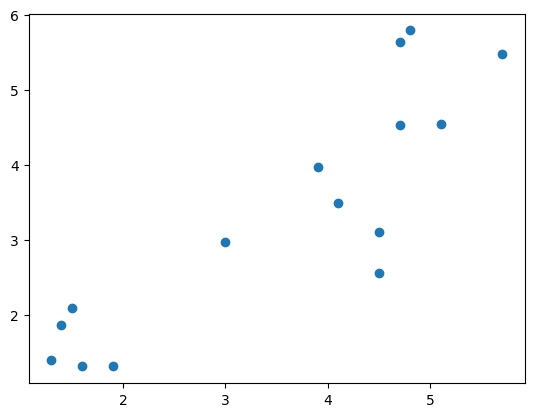

In [31]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
x_train_scaled = scaler.fit_transform(x_train.values)

# --- IMPORTANT ---
# Use that *same* scaler to transform your test data
x_test_scaled = scaler.transform(x_test.values)

# Now, train your model on the SCALED data
model = PolynomialRegression(optimizer = "adam")
model.fit(x_train_scaled, y_train.values.ravel(), epochs = 7000)

# And predict on the SCALED test data
predictions = model.predict(x_test_scaled)

# Now plot your results
plt.scatter(y_test, predictions)

In [32]:
predictions

array([2.97022992, 4.5277211 , 5.79126954, 4.54756167, 2.09410276,
       1.39371726, 5.48275966, 1.85948748, 2.54904891, 3.1044868 ,
       3.49476163, 1.30818792, 3.96909663, 1.30818792, 5.63308312])